In [1]:
import os
import glob
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Canonical reward parameters (define once here for notebook-wide tests)
# Edit these to change reward behaviour across all tests in this notebook
REWARD_PARAMS = {
    'goal_threshold': 0.3,
    'goal_reward_base': 5.0,
    'goal_distance_reference': 5.0,
    'use_scaled_goal': True,
    'distance_reward_scale': 5.0,
    'jerk_scale': 0.01,
    'obstacle_scale': 0.3,
    'gait_switch_penalty': 0.1,
    'instability_scale': 0.02,
    'time_penalty': 0.01,
    'velocity_error_scale': 0.01,
    'collision_penalty': 0.5,
    'normalize_distance': True
}

# Also create top-level variables for convenience
for k, v in REWARD_PARAMS.items():
    globals()[k] = v

print("Canonical REWARD_PARAMS defined for this notebook.")

Canonical REWARD_PARAMS defined for this notebook.


In [3]:
# Configuration
RECORDED_DATA_DIR = "/home/maurits-heemskerk/Documents/Uni/Master_Thesis/openbots_backpack/src/packages/dataset/recorded_data"

# Find all HDF5 files and ROS bags
h5_files = glob.glob(os.path.join(RECORDED_DATA_DIR, "**/*.h5"), recursive=True)
bag_dirs = [d for d in glob.glob(os.path.join(RECORDED_DATA_DIR, "*")) if os.path.isdir(d)]

print(f"Found {len(h5_files)} HDF5 files")
print(f"Found {len(bag_dirs)} ROS bag directories")

if h5_files:
    print("\nHDF5 Files:")
    for f in sorted(h5_files, key=os.path.getmtime, reverse=True):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"  - {os.path.basename(f)} ({size_mb:.2f} MB)")
        
if bag_dirs:
    print("\nROS Bag Directories:")
    for d in sorted(bag_dirs, key=os.path.getmtime, reverse=True)[:5]:
        print(f"  - {os.path.basename(d)}")

Found 1 HDF5 files
Found 0 ROS bag directories

HDF5 Files:
  - spot_bag_20260217_132229_expert_med_converted.h5 (1.69 MB)


In [4]:
def load_h5_episode(h5_path, max_retries=3, retry_delay=1.0):
    """Load episode data from HDF5 file with retry logic for locked files"""
    import time
    print(f"Loading: {os.path.basename(h5_path)}")
    
    # Retry logic in case file is locked
    for attempt in range(max_retries):
        try:
            episode = {}
            with h5py.File(h5_path, 'r', swmr=False) as f:
                # Print available datasets
                print("Available datasets:")
                def print_structure(name, obj):
                    if isinstance(obj, h5py.Dataset):
                        print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
                f.visititems(print_structure)
                
                # Load observations
                obs_keys = ['state', 'velocities', 'actions', 'timestamps', 'locomotion_mode']
                for key in obs_keys:
                    path = f'observations/{key}' if 'observations' in f else key
                    if path in f:
                        episode[key] = f[path][()]
                    elif key in f:
                        episode[key] = f[key][()]
                    else:
                        if key != 'locomotion_mode':  # Don't warn about optional locomotion_mode
                            print(f"  Warning: {key} not found")
                
                # Load actions separately
                if 'actions' not in episode and 'actions' in f:
                    episode['actions'] = f['actions'][()]
                
                # Load local grids
                if 'observations/obstacle_grids' in f:
                    episode['obstacle_grids'] = f['observations/obstacle_grids'][()]
                if 'observations/terrain_grids' in f:
                    episode['terrain_grids'] = f['observations/terrain_grids'][()]
                    print(f"  ✓ Loaded terrain grids: {episode['terrain_grids'].shape}")
                
                # Load collision events
                if 'observations/collision_events' in f:
                    episode['collision_events'] = f['observations/collision_events'][()]
                    print(f"  ✓ Loaded collision events: {episode['collision_events'].shape}")
                elif 'collision_events' in f:
                    episode['collision_events'] = f['collision_events'][()]
                    print(f"  ✓ Loaded collision events: {episode['collision_events'].shape}")
                else:
                    print(f"  ⚠ Collision events not found in HDF5")
                
                # Load camera images - THIS IS CRITICAL FOR VISUALIZATION
                print("\nLoading sensor images and depth maps...")
                if 'observations/images_front' in f:
                    print(f"  Found observations/images_front, loading...")
                    episode['images_front'] = f['observations/images_front'][()]
                    print(f"  ✓ Loaded front camera: {episode['images_front'].shape}")
                else:
                    print(f"  ✗ observations/images_front not found")
                    
                if 'observations/image' in f:
                    episode['image'] = f['observations/image'][()]
                    print(f"  ✓ Loaded image: {episode['image'].shape}")
                
                # Load depth maps
                if 'observations/depth_registered_left' in f:
                    print(f"  Found observations/depth_registered_left, loading...")
                    episode['depth_registered_left'] = f['observations/depth_registered_left'][()]
                    print(f"  ✓ Loaded depth left: {episode['depth_registered_left'].shape}")
                else:
                    print(f"  ✗ observations/depth_registered_left not found")
                    
                if 'observations/depth_registered_right' in f:
                    print(f"  Found observations/depth_registered_right, loading...")
                    episode['depth_registered_right'] = f['observations/depth_registered_right'][()]
                    print(f"  ✓ Loaded depth right: {episode['depth_registered_right'].shape}")
                else:
                    print(f"  ✗ observations/depth_registered_right not found")
            
            return episode
        except (BlockingIOError, OSError) as e:
            if attempt < max_retries - 1:
                print(f"  File locked (attempt {attempt+1}/{max_retries}), retrying in {retry_delay}s...")
                time.sleep(retry_delay)
            else:
                print(f"  ✗ Failed to load file after {max_retries} attempts: {e}")
                raise

# Select the latest HDF5 file if available
if h5_files:
    selected_h5 = sorted(h5_files, key=os.path.getmtime, reverse=True)[0]
    print(f"\nLoading latest HDF5: {selected_h5}")
    episode_data = load_h5_episode(selected_h5)
    data_loaded_from = "H5"
else:
    print("No HDF5 files found. You'll need to convert a rosbag first.")
    print("Run: python convert_bag_to_hdf5.py <bag_path> --output <output_dir>")
    episode_data = None
    data_loaded_from = None


Loading latest HDF5: /home/maurits-heemskerk/Documents/Uni/Master_Thesis/openbots_backpack/src/packages/dataset/recorded_data/spot_bag_20260217_132229_expert_med_converted.h5
Loading: spot_bag_20260217_132229_expert_med_converted.h5
Available datasets:
  actions: shape=(67, 4), dtype=float32
  observations/collision_events: shape=(67,), dtype=bool
  observations/images_front: shape=(67, 49, 128, 3), dtype=uint8
  observations/locomotion_mode: shape=(67,), dtype=uint32
  observations/state: shape=(67, 7), dtype=float32
  observations/terrain_grids: shape=(67, 64, 64), dtype=float32
  observations/velocities: shape=(67, 6), dtype=float32
  timestamps: shape=(67,), dtype=float64
  ✓ Loaded terrain grids: (67, 64, 64)
  ✓ Loaded collision events: (67,)

Loading sensor images and depth maps...
  Found observations/images_front, loading...
  ✓ Loaded front camera: (67, 49, 128, 3)
  ✗ observations/depth_registered_left not found
  ✗ observations/depth_registered_right not found


In [5]:
# Extract episode components
if episode_data:
    timestamps = episode_data.get('timestamps', np.arange(len(episode_data['state'])))
    states = episode_data['state']  # [N, 7] = [x, y, z, qx, qy, qz, qw]
    velocities = episode_data.get('velocities', None)  # [N, 6]
    actions = episode_data.get('actions', None)  # [N, 6]
    # Try both 'terrain_grids' and 'obstacle_grids' keys (depends on converter version)
    # NOTE: Terrain grids are already normalized at H5 conversion time (ground level = 0)
    obstacle_grids = episode_data.get('terrain_grids', episode_data.get('obstacle_grids', None))  # [N, H, W]
    collision_events = episode_data.get('collision_events', None)  # [N] boolean array of collision flags
    
    # Normalize time to start from 0 (visualization purposes only)
    timestamps = timestamps - timestamps[0]
    
    # Normalize position to start from (0, 0, 0)
    initial_position = states[0, :3].copy()
    states = states.copy()
    states[:, :3] = states[:, :3] - initial_position
    
    n_steps = len(states)
    print(f"\nEpisode Summary (Normalized):")
    print(f"  Steps: {n_steps}")
    print(f"  State shape: {states.shape}")
    print(f"  Velocities: {velocities.shape if velocities is not None else 'Not available'}")
    print(f"  Actions: {actions.shape if actions is not None else 'Not available'}")
    print(f"  Obstacle grids: {obstacle_grids.shape if obstacle_grids is not None else 'Not available'}")
    if obstacle_grids is not None:
        print(f"  Obstacle grids (min-max): {np.nanmin(obstacle_grids):.3f} to {np.nanmax(obstacle_grids):.3f}")
        print(f"  ✓ Terrain pre-normalized at H5 conversion (ground level = 0)")
    print(f"  Collision events: {collision_events.shape if collision_events is not None else 'Not available'}")
    if collision_events is not None:
        n_collisions = np.sum(collision_events)
        print(f"  ✓ Collision flags detected: {n_collisions} events")
    print(f"  Time range: {timestamps[0]:.2f} to {timestamps[-1]:.2f} seconds")
    print(f"  Start position (normalized): {states[0, :3]}")
    print(f"  Initial raw position: {initial_position}")
else:
    n_steps = 0
    print("No episode data loaded")


Episode Summary (Normalized):
  Steps: 67
  State shape: (67, 7)
  Velocities: (67, 6)
  Actions: (67, 4)
  Obstacle grids: (67, 64, 64)
  Obstacle grids (min-max): 0.000 to 1.537
  ✓ Terrain pre-normalized at H5 conversion (ground level = 0)
  Collision events: (67,)
  ✓ Collision flags detected: 0 events
  Time range: 0.00 to 22.02 seconds
  Start position (normalized): [0. 0. 0.]
  Initial raw position: [0. 0. 0.]


## Section 2a: Sensor Observations with Normalized Data

Visualize sample sensor data (camera images and terrain grids) alongside normalized time and position - before reward computation.


Sensor data available:
  Images front: (67, 49, 128, 3)
  Depth left: Not available
  Depth right: Not available
  Terrain grids: (67, 64, 64)
  Terrain grids (min-max): 0.000 to 1.537
  ✓ Pre-normalized at H5 conversion (ground level = 0)
  Total steps: 67
  Using 4 sample indices from 67 available frames


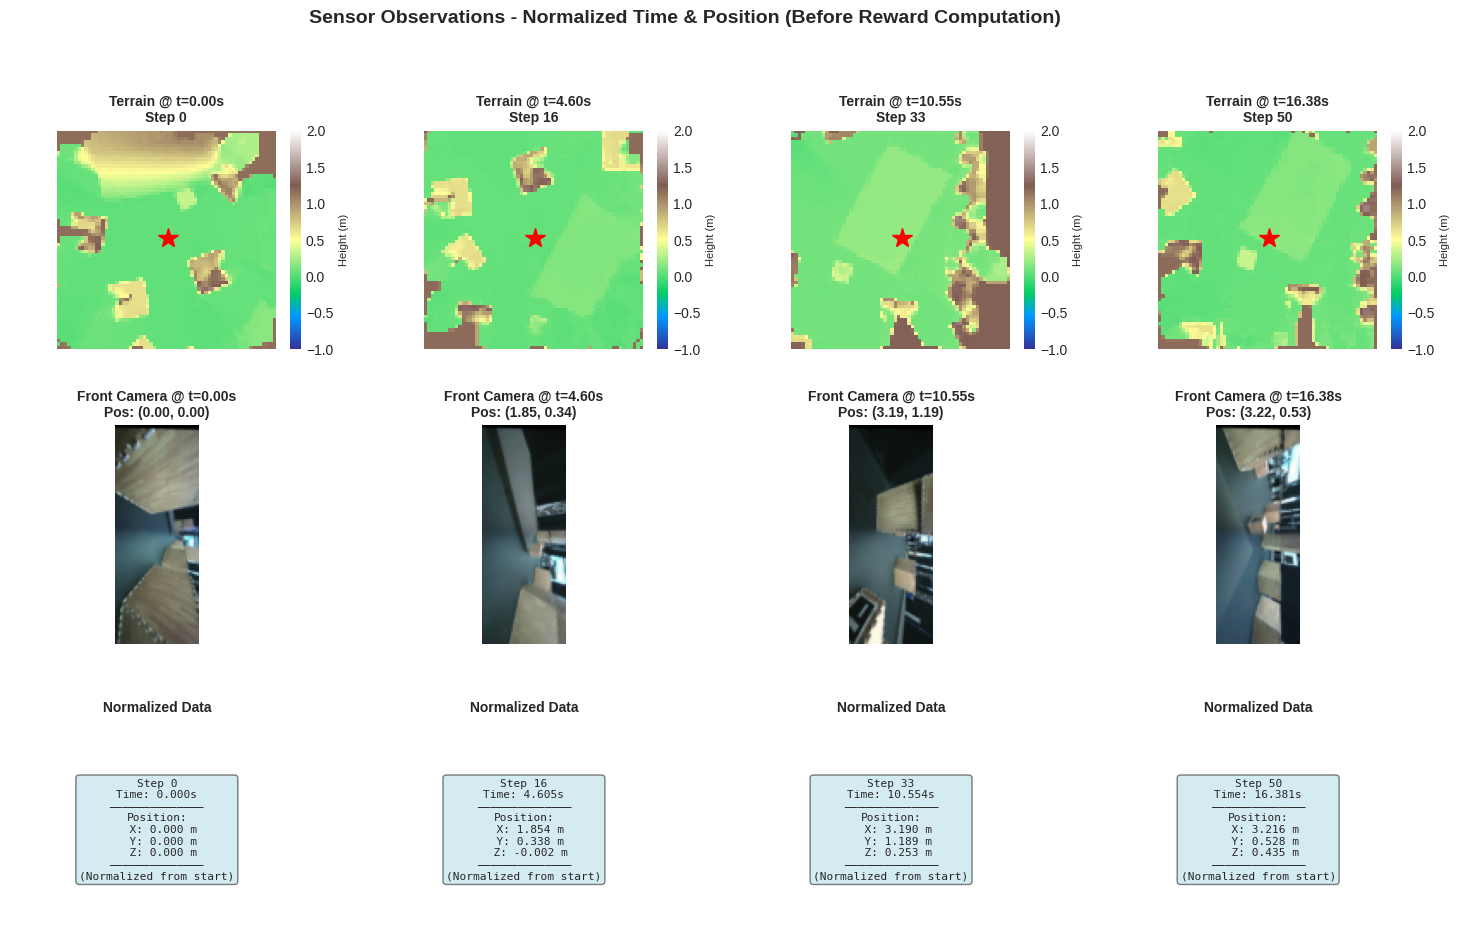

Sensor visualization saved!


In [6]:
if episode_data:
    # Load sensor data if available
    images_front = episode_data.get('images_front', None)
    depth_left = episode_data.get('depth_registered_left', None)
    depth_right = episode_data.get('depth_registered_right', None)
    # Use the already-normalized obstacle_grids from data loading section
    terrain_grids = obstacle_grids  # Already normalized to ground=0
    
    # Debug: Check what was loaded
    print("Sensor data available:")
    print(f"  Images front: {images_front.shape if images_front is not None else 'Not available'}")
    print(f"  Depth left: {depth_left.shape if depth_left is not None else 'Not available'}")
    print(f"  Depth right: {depth_right.shape if depth_right is not None else 'Not available'}")
    print(f"  Terrain grids: {terrain_grids.shape if terrain_grids is not None else 'Not available'}")
    if terrain_grids is not None:
        print(f"  Terrain grids (min-max): {np.nanmin(terrain_grids):.3f} to {np.nanmax(terrain_grids):.3f}")
        print(f"  ✓ Pre-normalized at H5 conversion (ground level = 0)")
    print(f"  Total steps: {n_steps}")
    
    # Select sample indices from the episode - align with available data
    max_len = max(
        len(images_front) if images_front is not None else 0,
        len(depth_left) if depth_left is not None else 0,
        len(terrain_grids) if terrain_grids is not None else 0,
        n_steps
    )
    
    num_samples = min(max_len, n_steps) if max_len > 0 else 0
    sample_indices = [0, num_samples // 4, num_samples // 2, 3 * num_samples // 4] if num_samples > 0 else []
    print(f"  Using {len(sample_indices)} sample indices from {num_samples} available frames")
    
    if sample_indices:
        # Determine how many rows we actually need
        n_rows = 0
        if terrain_grids is not None:
            n_rows += 1
        if images_front is not None:
            n_rows += 1
        if depth_left is not None:
            n_rows += 1
        n_rows += 1  # Always add reward breakdown row (will show 0 since not computed yet)
        
        fig = plt.figure(figsize=(18, 3.5 * n_rows))
        gs = fig.add_gridspec(n_rows, 4, hspace=0.35, wspace=0.25)
        
        row = 0
        
        # Row: Terrain grids with normalized height
        if terrain_grids is not None:
            for col, idx in enumerate(sample_indices):
                ax = fig.add_subplot(gs[row, col])
                grid = terrain_grids[idx]
                im = ax.imshow(grid, cmap='terrain', origin='lower', vmin=-1, vmax=2)
                ax.plot(grid.shape[1]//2, grid.shape[0]//2, 'r*', markersize=15, label='Robot (h=0)')
                ax.set_title(f'Terrain @ t={timestamps[idx]:.2f}s\nStep {idx}', fontsize=10, fontweight='bold')
                ax.axis('off')
                cbar = plt.colorbar(im, ax=ax, fraction=0.046)
                cbar.set_label('Height (m)', fontsize=8)
            row += 1
        
        # Row: Front camera images
        if images_front is not None:
            for col, idx in enumerate(sample_indices):
                ax = fig.add_subplot(gs[row, col])
                img = images_front[idx]
                # Rotate clockwise 90 degrees
                img_rotated = np.rot90(img, k=-1)
                # Handle different image formats
                if img_rotated.dtype == np.uint8:
                    ax.imshow(img_rotated)
                else:
                    # Normalize if needed
                    img_norm = (img_rotated - img_rotated.min()) / (img_rotated.max() - img_rotated.min() + 1e-6)
                    ax.imshow(img_norm)
                ax.set_title(f'Front Camera @ t={timestamps[idx]:.2f}s\nPos: ({states[idx, 0]:.2f}, {states[idx, 1]:.2f})', fontsize=10, fontweight='bold')
                ax.axis('off')
            row += 1
        
        # Row: Depth maps (left)
        if depth_left is not None:
            for col, idx in enumerate(sample_indices):
                ax = fig.add_subplot(gs[row, col])
                depth = depth_left[idx]
                # Rotate clockwise 90 degrees
                depth_rotated = np.rot90(depth, k=-1)
                im = ax.imshow(depth_rotated, cmap='viridis')
                ax.set_title(f'Depth Left @ t={timestamps[idx]:.2f}s\nH: {states[idx, 2]:.2f}m', fontsize=10, fontweight='bold')
                ax.axis('off')
                plt.colorbar(im, ax=ax, fraction=0.046)
            row += 1
        
        # Row: Position info
        for col, idx in enumerate(sample_indices):
            ax = fig.add_subplot(gs[row, col])
            pos_text = (
                f"Step {idx}\n"
                f"Time: {timestamps[idx]:.3f}s\n"
                f"──────────────\n"
                f"Position:\n"
                f"  X: {states[idx, 0]:.3f} m\n"
                f"  Y: {states[idx, 1]:.3f} m\n"
                f"  Z: {states[idx, 2]:.3f} m\n"
                f"──────────────\n"
                f"(Normalized from start)"
            )
            ax.text(0.5, 0.5, pos_text, fontsize=8, ha='center', va='center', 
                   family='monospace', transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
            ax.axis('off')
            ax.set_title('Normalized Data', fontsize=10, fontweight='bold')
        
        fig.suptitle('Sensor Observations - Normalized Time & Position (Before Reward Computation)', fontsize=14, fontweight='bold', y=0.995)
        plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/sensor_normalized.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        
        print("Sensor visualization saved!")
    else:
        print("No sample indices available")
else:
    print("No episode data available")

In [7]:
class RewardComputer:
    """Computes multi-component rewards for SPOT robot episodes"""
    
    def __init__(self, goal_threshold=0.5, goal_reward_base=3.0, goal_distance_reference=5.0,
                 jerk_scale=0.01, obstacle_scale=0.3, distance_reward_scale=5.0, gait_switch_penalty=0.1, 
                 instability_scale=0.02, time_penalty=0.01, velocity_error_scale=0.01, 
                 collision_penalty=0.5, normalize_distance=True, use_scaled_goal=True):
        self.goal_position = None
        self.goal_threshold = goal_threshold  # Distance threshold for goal reaching
        self.goal_reward_base = goal_reward_base  # Base reward for reaching goal (at reference distance)
        self.goal_distance_reference = goal_distance_reference  # Reference distance for scaling (5.0m)
        self.use_scaled_goal = use_scaled_goal  # Enable distance-scaled goal reward
        self.jerk_scale = jerk_scale  # Scale for jerk penalty on action commands (0.01)
        self.obstacle_scale = obstacle_scale  # Scale for obstacle penalty
        self.distance_reward_scale = distance_reward_scale  # Scale for distance decrease reward (5.0)
        self.gait_switch_penalty = gait_switch_penalty  # Penalty per gait switch
        self.instability_scale = instability_scale  # Scale for instability (angular velocity changes) - INCREASED to 0.02
        self.time_penalty = time_penalty  # Small penalty per step (encourages speed)
        self.velocity_error_scale = velocity_error_scale  # Scale for velocity/action alignment penalty
        self.collision_penalty = collision_penalty  # Penalty for marked collision events (0.5)
        self.normalize_distance = normalize_distance  # Normalize distance reward by initial distance
        self.initial_distance_to_goal = None  # Will be set when goal is set
    
    def goal_reaching_reward_array(self, states):
        """
        Goal reaching reward: +goal_reward ONCE when first entering goal region
        One-time bonus when robot first reaches the goal (not per frame)
        
        Supports distance-scaled reward: goal_reward = goal_reward_base * (initial_distance / reference_distance)
        Compensates for longer episodes which accumulate more time penalty.
        
        Args:
            states: [N, 7] state array with positions [x, y, z, qx, qy, qz, qw]
        Returns:
            [N] array with single reward spike at first goal achievement
        """
        if self.goal_position is None or states is None or len(states) == 0:
            return np.zeros(len(states) if states is not None else 0)
        
        positions = states[:, :3]
        goal_pos = np.array(self.goal_position[:3])
        
        # Compute distances to goal at each timestep
        distances = np.linalg.norm(positions - goal_pos, axis=1)
        
        # Find first timestep where robot enters goal region
        in_goal_region = distances < self.goal_threshold
        goal_rewards = np.zeros(len(states))
        
        # Only reward at the first entry into goal region
        if np.any(in_goal_region):
            first_goal_idx = np.argmax(in_goal_region)
            
            # Compute goal reward (fixed or distance-scaled)
            if hasattr(self, 'use_scaled_goal') and self.use_scaled_goal:
                initial_distance = distances[0]
                goal_reward = self.goal_reward_base * (initial_distance / self.goal_distance_reference)
            elif hasattr(self, 'goal_reward_base'):
                goal_reward = self.goal_reward_base
            else:
                goal_reward = self.goal_reward  # Fallback for old versions
            
            goal_rewards[first_goal_idx] = goal_reward
        
        return goal_rewards
    
    def action_smoothness_penalty(self, actions):
        """
        Action smoothness penalty: penalizes jerky commands from the policy
        Computed from actor's control commands, not odometry (fairer metric)
        Large changes in consecutive actions indicate jerky policy outputs
        
        Args:
            actions: [N, 6] action array (policy outputs: velocities/accelerations)
        Returns:
            [N] array of action jerk penalties
        """
        if actions is None or len(actions) < 2:
            return np.zeros(len(actions) if actions is not None else 0)
        
        # Compute action differences (command jerk/acceleration)
        action_diffs = np.diff(actions, axis=0)
        
        # Magnitude of action change at each timestep
        action_change_magnitude = np.linalg.norm(action_diffs, axis=1)
        
        # Apply sqrt for sublinear penalty (gentler on large changes)
        jerk_penalties = -self.jerk_scale * np.sqrt(action_change_magnitude)
        
        # Pad to match input length
        jerk_penalties = np.pad(jerk_penalties, (1, 0), mode='constant', constant_values=0)
        return jerk_penalties
    
    def obstacle_avoidance_penalty(self, obstacle_grids, obstacle_threshold=0.4):
        """
        Obstacle collision penalty: penalizes when robot hits an obstacle at its center.
        
        Only penalizes if the obstacle avoidance node failed and the robot aggressively
        collided with terrain it cannot climb (>40cm height obstacles at robot center).
        
        Uses center-only detection: only checks if there's a non-climbable obstacle
        directly under the robot at the grid center.
        
        Args:
            obstacle_grids: [N, H, W] terrain height grids (normalized, ground=0)
            obstacle_threshold: Height threshold for non-climbable obstacles (0.4m = 40cm)
                               Robot can climb anything <= 40cm, penalty only for higher obstacles
        Returns:
            [N] array of obstacle penalties (-penalty if obstacle at center, 0 otherwise)
        """
        if obstacle_grids is None or len(obstacle_grids) == 0:
            return np.zeros(len(obstacle_grids) if obstacle_grids is not None else 0)
        
        # Grid information: 4m x 4m terrain grid
        grid_h, grid_w = obstacle_grids[0].shape
        grid_size_m = 4.0  # meters
        grid_resolution = grid_size_m / grid_h  # meters per grid cell
        
        penalties = []
        for grid in obstacle_grids:
            if grid.size == 0:
                penalties.append(0.0)
            else:
                h, w = grid.shape
                # Robot is at center of grid
                center_y = int(h / 2)
                center_x = int(w / 2)
                
                # Check terrain height at robot center
                center_height = grid[center_y, center_x]
                
                # Penalize only if there's a valid non-climbable obstacle at center
                if not np.isnan(center_height):
                    if center_height > obstacle_threshold:
                        # Obstacle higher than robot can climb
                        # Penalty magnitude based on obstacle height
                        excess_height = center_height - obstacle_threshold
                        penalty = -self.obstacle_scale * excess_height
                    else:
                        # Climbable terrain, no penalty
                        penalty = 0.0
                else:
                    # Invalid height data at center, assume safe
                    penalty = 0.0
                
                penalties.append(penalty)
        
        return np.array(penalties)
    
    def distance_decrease_reward(self, states):
        """
        Reward for moving closer to goal (encourages exploration and movement toward target)
        Positive reward when distance to goal decreases
        This is the primary reward signal for learning to move toward goal
        
        Args:
            states: [N, 7] state array with positions [x, y, z, qx, qy, qz, qw]
        Returns:
            [N] array of distance decrease rewards
        """
        if self.goal_position is None or states is None or len(states) < 2:
            return np.zeros(len(states) if states is not None else 0)
        
        positions = states[:, :3]
        goal_pos = np.array(self.goal_position[:3])
        
        # Compute distances to goal at each timestep
        distances = np.linalg.norm(positions - goal_pos, axis=1)
        
        # Calculate initial distance if normalizing
        if self.normalize_distance:
            initial_distance = distances[0]
            if initial_distance < 1e-6:  # Avoid division by zero
                initial_distance = 1.0
            self.initial_distance_to_goal = initial_distance
        else:
            initial_distance = 1.0
        
        # Reward for decreasing distance
        distance_changes = np.diff(distances)
        # Negative distance_change means we're getting closer (good!)
        # Normalize by initial distance for fair comparison across episodes
        rewards = -self.distance_reward_scale * (distance_changes / initial_distance)
        
        # Pad to match input length
        rewards = np.pad(rewards, (1, 0), mode='constant', constant_values=0)
        return rewards
    
    def time_penalty_array(self, states):
        """
        Time penalty: small negative reward for each step (encourages speed)
        Encourages robot to reach goal quickly rather than taking detours
        
        Args:
            states: [N, 7] state array with positions [x, y, z, qx, qy, qz, qw]
        Returns:
            [N] array with constant time penalty per step
        """
        if states is None or len(states) == 0:
            return np.zeros(len(states) if states is not None else 0)
        
        # Apply small negative reward for each step taken
        time_penalties = np.full(len(states), -self.time_penalty)
        
        return time_penalties
    
    def gait_switching_penalty(self, locomotion_modes):
        """
        Penalty for switching between different gaits (wastes energy/momentum)
        
        Args:
            locomotion_modes: [N] array of locomotion mode indices
        Returns:
            [N] array of gait switching penalties
        """
        if locomotion_modes is None or len(locomotion_modes) < 2:
            return np.zeros(len(locomotion_modes) if locomotion_modes is not None else 0)
        
        # Detect mode changes
        mode_changes = np.diff(locomotion_modes) != 0
        penalties = np.zeros(len(locomotion_modes))
        
        # Penalize the timestep where the change occurs
        penalties[1:][mode_changes] = -self.gait_switch_penalty
        
        return penalties
    
    def instability_penalty(self, states):
        """
        Penalty for instability: large angular velocity (rolling/pitching/yawing)
        Encourages smooth, stable motion
        
        Args:
            states: [N, 7] state array [x, y, z, qx, qy, qz, qw] (quaternion rotation)
        Returns:
            [N] array of instability penalties
        """
        if states is None or len(states) < 2:
            return np.zeros(len(states) if states is not None else 0)
        
        # Extract quaternions and compute angular velocity from quaternion changes
        quats = states[:, 3:7]  # [qx, qy, qz, qw]
        
        # Quaternion differences (represents rotation changes)
        quat_diffs = np.diff(quats, axis=0)
        
        # Magnitude of quaternion change (related to angular velocity magnitude)
        quat_change_magnitude = np.linalg.norm(quat_diffs, axis=1)
        
        # Penalize large rotations (instability)
        instability_penalties = -self.instability_scale * quat_change_magnitude
        
        # Pad to match input length
        instability_penalties = np.pad(instability_penalties, (1, 0), mode='constant', constant_values=0)
        return instability_penalties
    
    def velocity_alignment_penalty(self, velocities, actions):
        """
        Velocity/action alignment penalty: penalizes discrepancy between commanded and actual velocity
        
        Encourages smooth motion and proper gait selection:
        - Fast gait (2 m/s): for high-speed movement in open areas
        - Slow gait (1 m/s): for careful movement in tight spaces
        
        When robot velocity matches commanded velocity, low penalty.
        When there's mismatch, higher penalty encourages better motion coordination.
        
        Args:
            velocities: [N, 6] actual odometry velocities [vx, vy, vz, wx, wy, wz]
            actions: [N, 4] commanded action velocities [vx_cmd, vy_cmd, vyaw_cmd, gait_selection]
        Returns:
            [N] array of velocity alignment penalties
        """
        if velocities is None or actions is None or len(velocities) < 1:
            return np.zeros(len(velocities) if velocities is not None else 0)
        
        # Extract relevant dimensions to match commanded actions
        # actions[:, 0:3] = [vx_cmd, vy_cmd, vyaw_cmd] 
        # velocities[:, [0, 1, 5]] = [vx, vy, wz] (where wz is yaw rate)
        vel_relevant = velocities[:, [0, 1, 5]]
        act_relevant = actions[:, 0:3]
        
        # Compute velocity error magnitude (Euclidean distance between commanded and actual)
        velocity_errors = np.linalg.norm(vel_relevant - act_relevant, axis=1)
        
        # Apply squared penalty to penalize larger errors more heavily
        # This encourages the robot to execute commands smoothly
        alignment_penalties = -self.velocity_error_scale * (velocity_errors ** 2)
        
        return alignment_penalties
    
    def collision_event_penalty(self, collision_events):
        """
        Penalty for marked collision events (user flagged collisions)
        
        Args:
            collision_events: [N] boolean array where True indicates collision flagged
        Returns:
            [N] array of collision penalties (-0.5 where collision is True, 0 otherwise)
        """
        if collision_events is None or len(collision_events) == 0:
            return np.zeros(len(collision_events) if collision_events is not None else 0)
        
        # Convert to float and apply penalty where collision_events is True
        collision_penalties = np.where(collision_events, -self.collision_penalty, 0.0)
        return collision_penalties

print("RewardComputer class defined!")

RewardComputer class defined!


## Section 1b: Interactive Timestep Viewer

Select a specific timestep to visualize terrain map and camera image at that exact moment.


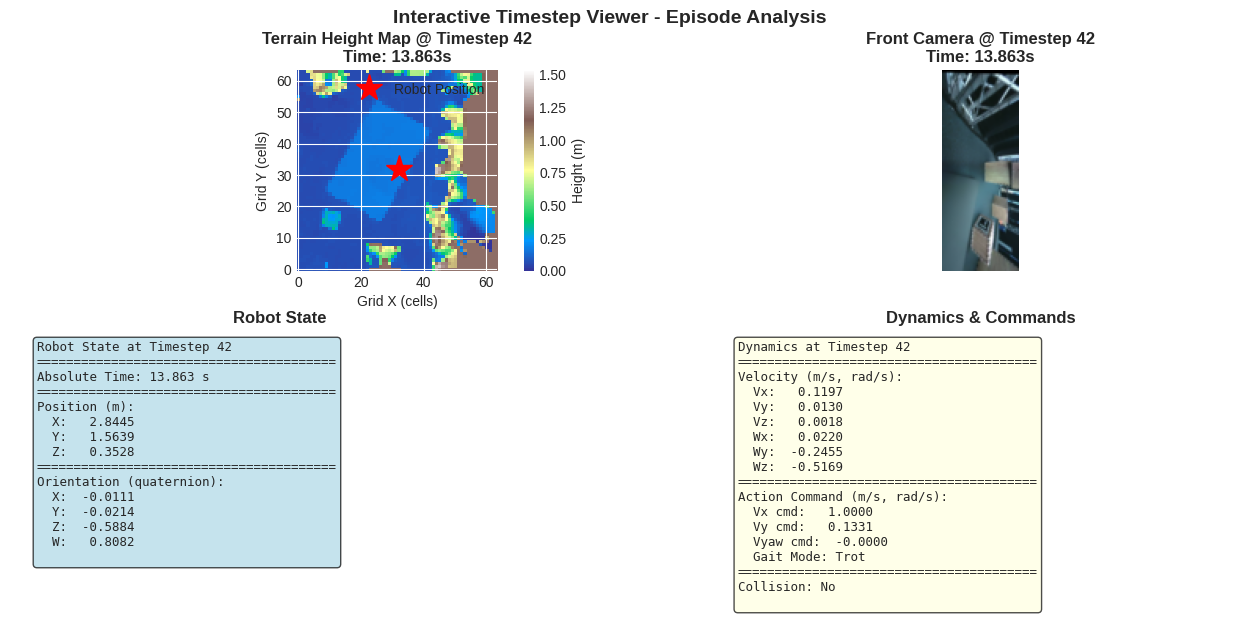

✓ Timestep 42 visualization complete!


In [8]:
        # ===== TIMESTEP SELECTOR - Edit this variable to view any timestep =====
        selected_timestep = 42  # Change this to any valid timestep (0 to n_steps-1)
        # =========================================================================

        if episode_data and n_steps > 0:
            # Load locomotion modes if not already loaded
            if 'locomotion_modes' not in locals() or locomotion_modes is None:
                locomotion_modes = episode_data.get('locomotion_mode', None)
            
            # Validate timestep
            if selected_timestep < 0 or selected_timestep >= n_steps:
                print(f"ERROR: Invalid timestep {selected_timestep}. Valid range: 0 to {n_steps-1}")
            else:
                idx = selected_timestep
                
                # Create figure with terrain + camera
                fig = plt.figure(figsize=(16, 6))
                gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
                
                # 1. Terrain Grid
                if terrain_grids is not None and idx < len(terrain_grids):
                    ax1 = fig.add_subplot(gs[0, 0])
                    grid = terrain_grids[idx]
                    im1 = ax1.imshow(grid, cmap='terrain', origin='lower', vmin=np.nanmin(terrain_grids), vmax=np.nanmax(terrain_grids))
                    ax1.plot(grid.shape[1]//2, grid.shape[0]//2, 'r*', markersize=20, label='Robot Position')
                    ax1.set_title(f'Terrain Height Map @ Timestep {idx}\nTime: {timestamps[idx]:.3f}s', fontsize=12, fontweight='bold')
                    ax1.set_xlabel('Grid X (cells)')
                    ax1.set_ylabel('Grid Y (cells)')
                    ax1.legend(fontsize=10)
                    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046)
                    cbar1.set_label('Height (m)', fontsize=10)
                
                # 2. Front Camera Image
                if images_front is not None and idx < len(images_front):
                    ax2 = fig.add_subplot(gs[0, 1])
                    img = images_front[idx]
                    img_rotated = np.rot90(img, k=-1)
                    # Handle different image formats
                    if img_rotated.dtype == np.uint8:
                        ax2.imshow(img_rotated)
                    else:
                        img_norm = (img_rotated - img_rotated.min()) / (img_rotated.max() - img_rotated.min() + 1e-6)
                        ax2.imshow(img_norm)
                    ax2.set_title(f'Front Camera @ Timestep {idx}\nTime: {timestamps[idx]:.3f}s', fontsize=12, fontweight='bold')
                    ax2.axis('off')
                
                # 3. Robot State Information
                ax3 = fig.add_subplot(gs[1, 0])
                state_text = (
                    f"Robot State at Timestep {idx}\n"
                    f"{'='*40}\n"
                    f"Absolute Time: {timestamps[idx]:.3f} s\n"
                    f"{'='*40}\n"
                    f"Position (m):\n"
                    f"  X: {states[idx, 0]:8.4f}\n"
                    f"  Y: {states[idx, 1]:8.4f}\n"
                    f"  Z: {states[idx, 2]:8.4f}\n"
                    f"{'='*40}\n"
                    f"Orientation (quaternion):\n"
                    f"  X: {states[idx, 3]:8.4f}\n"
                    f"  Y: {states[idx, 4]:8.4f}\n"
                    f"  Z: {states[idx, 5]:8.4f}\n"
                    f"  W: {states[idx, 6]:8.4f}\n"
                )
                ax3.text(0.05, 0.95, state_text, fontsize=9, family='monospace', 
                        transform=ax3.transAxes, va='top',
                        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
                ax3.axis('off')
                ax3.set_title('Robot State', fontsize=12, fontweight='bold')
                
                # 4. Velocity & Action Information (4D action space: [vx, vy, vyaw, gait_selection])
                ax4 = fig.add_subplot(gs[1, 1])
                gait_idx = int(actions[idx, 3])
                gait_mode = ['Crawl', 'Trot'][gait_idx] if gait_idx in [0, 1] else f'Unknown ({gait_idx})'
                
                vel_action_text = (
                    f"Dynamics at Timestep {idx}\n"
                    f"{'='*40}\n"
                    f"Velocity (m/s, rad/s):\n"
                    f"  Vx: {velocities[idx, 0]:8.4f}\n"
                    f"  Vy: {velocities[idx, 1]:8.4f}\n"
                    f"  Vz: {velocities[idx, 2]:8.4f}\n"
                    f"  Wx: {velocities[idx, 3]:8.4f}\n"
                    f"  Wy: {velocities[idx, 4]:8.4f}\n"
                    f"  Wz: {velocities[idx, 5]:8.4f}\n"
                    f"{'='*40}\n"
                    f"Action Command (m/s, rad/s):\n"
                    f"  Vx cmd: {actions[idx, 0]:8.4f}\n"
                    f"  Vy cmd: {actions[idx, 1]:8.4f}\n"
                    f"  Vyaw cmd: {actions[idx, 2]:8.4f}\n"
                    f"  Gait Mode: {gait_mode}\n"
                    f"{'='*40}\n"
                )
                
                # Add collision info if available
                if collision_events is not None and idx < len(collision_events):
                    collision_str = 'YES ⚠️' if collision_events[idx] else 'No'
                    vel_action_text += f"Collision: {collision_str}\n"
                
                ax4.text(0.05, 0.95, vel_action_text, fontsize=9, family='monospace',
                        transform=ax4.transAxes, va='top',
                        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
                ax4.axis('off')
                ax4.set_title('Dynamics & Commands', fontsize=12, fontweight='bold')
                
                fig.suptitle(f'Interactive Timestep Viewer - Episode Analysis', fontsize=14, fontweight='bold')
                plt.savefig(f'/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/timestep_{idx}_viewer.png',
                            dpi=150, bbox_inches='tight')
                plt.show()
                
                print(f"✓ Timestep {idx} visualization complete!")
        else:
            print("Cannot visualize: no episode data available or n_steps is 0")

## Section 1c: Reward Components Analysis (10 Components)

Comprehensive visualization of all reward signals throughout the episode.


Reward computation complete!
  Total episode reward: 5.87
  Mean reward per step: 0.0876
  Max step reward: 2.9314
  Min step reward: -0.3249


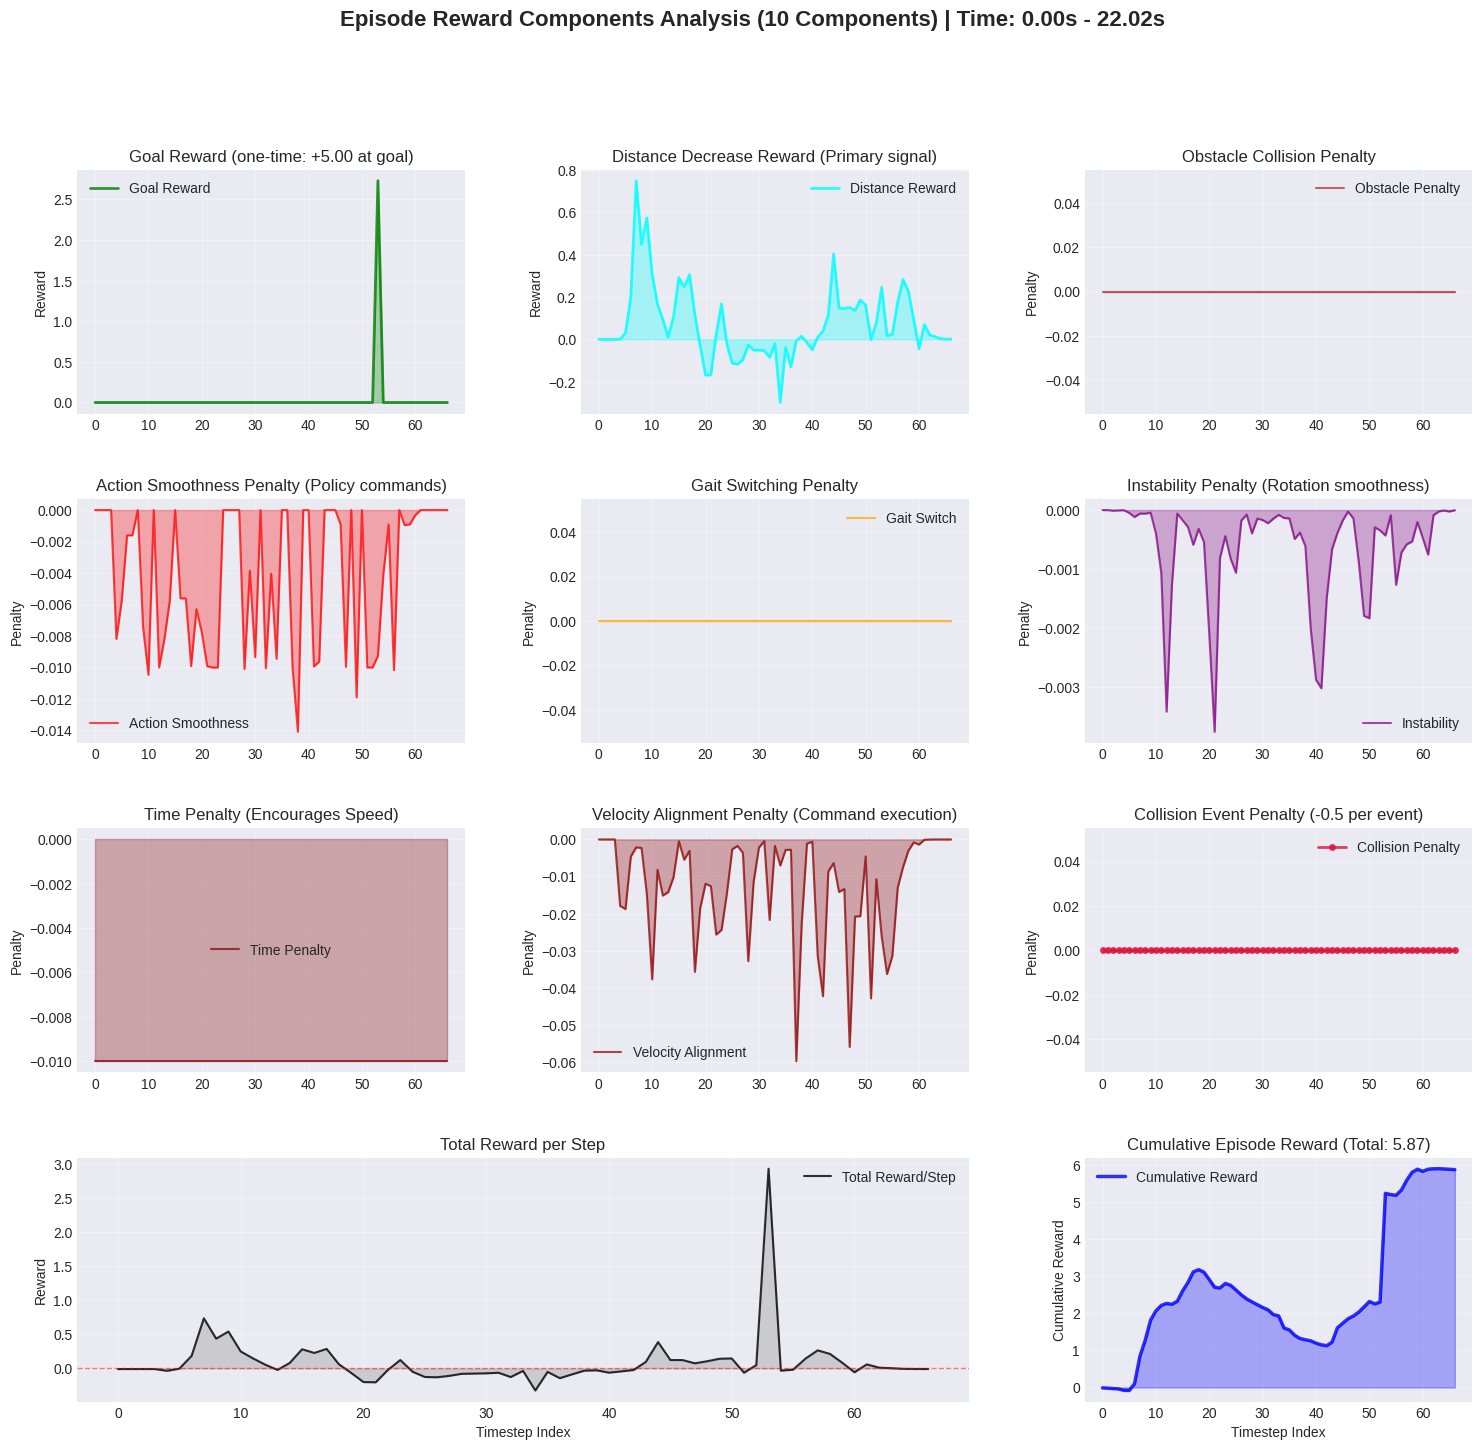

Visualization saved!


In [9]:
if episode_data and n_steps > 0:
    # ===== COMPUTE REWARD COMPONENTS =====
    # Initialize reward computer with goal position set to final position (explore behavior)
    reward_computer = RewardComputer(
        goal_reward_base=5.0,
        goal_distance_reference=5.0,
        use_scaled_goal=True,
        distance_reward_scale=5.0,
        jerk_scale=0.01,
        obstacle_scale=0.3,
        gait_switch_penalty=0.1,
        instability_scale=0.02,
        time_penalty=0.01,
        velocity_error_scale=0.04,
        collision_penalty=0.5,
        normalize_distance=True
    )
    
    # Set goal to final robot position (robot explores and we reward moving forward)
    reward_computer.goal_position = states[-1]  # Goal = final position in episode
    
    # Compute individual reward components
    goal_rewards = reward_computer.goal_reaching_reward_array(states)
    distance_rewards = reward_computer.distance_decrease_reward(states)
    obstacle_penalties = reward_computer.obstacle_avoidance_penalty(obstacle_grids)
    jerk_penalties = reward_computer.action_smoothness_penalty(actions)
    gait_penalties = reward_computer.gait_switching_penalty(locomotion_modes)
    instability_penalties = reward_computer.instability_penalty(states)
    time_penalties = reward_computer.time_penalty_array(states)
    velocity_alignment_penalties = reward_computer.velocity_alignment_penalty(velocities, actions)
    collision_penalties = reward_computer.collision_event_penalty(collision_events)
    
    # Compute total reward per step
    total_rewards = (goal_rewards + distance_rewards + obstacle_penalties + jerk_penalties + 
                     gait_penalties + instability_penalties + time_penalties + 
                     velocity_alignment_penalties + collision_penalties)
    
    # Compute cumulative reward
    cumulative_reward = np.cumsum(total_rewards)
    
    print(f"Reward computation complete!")
    print(f"  Total episode reward: {cumulative_reward[-1]:.2f}")
    print(f"  Mean reward per step: {np.mean(total_rewards):.4f}")
    print(f"  Max step reward: {np.max(total_rewards):.4f}")
    print(f"  Min step reward: {np.min(total_rewards):.4f}")
    
    # Create timestep index array
    timesteps = np.arange(len(timestamps))
    time_range = f"Time: {timestamps[0]:.2f}s - {timestamps[-1]:.2f}s"
    
    # Create comprehensive visualization (10 panels: 3x3 grid + cumulative at bottom)
    fig = plt.figure(figsize=(18, 16))
    fig.suptitle(f'Episode Reward Components Analysis (10 Components) | {time_range}', fontsize=16, fontweight='bold')
    
    # Create GridSpec for custom layout
    gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)
    
    # 1. Goal Reward
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(timesteps, goal_rewards, 'g-', linewidth=2, label='Goal Reward', alpha=0.8)
    ax.fill_between(timesteps, goal_rewards, alpha=0.3, color='green')
    ax.set_ylabel('Reward')
    display_goal = getattr(reward_computer, 'goal_reward_base', getattr(reward_computer, 'goal_reward', 5.0))
    ax.set_title(f'Goal Reward (one-time: +{display_goal:.2f} at goal)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Distance Reward
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(timesteps, distance_rewards, 'cyan', linewidth=2, label='Distance Reward', alpha=0.8)
    ax.fill_between(timesteps, distance_rewards, alpha=0.3, color='cyan')
    ax.set_ylabel('Reward')
    ax.set_title('Distance Decrease Reward (Primary signal)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Obstacle Penalty
    ax = fig.add_subplot(gs[0, 2])
    ax.plot(timesteps, obstacle_penalties, 'brown', linewidth=1.5, label='Obstacle Penalty', alpha=0.7)
    ax.fill_between(timesteps, obstacle_penalties, alpha=0.3, color='brown')
    ax.set_ylabel('Penalty')
    ax.set_title('Obstacle Collision Penalty')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Action Smoothness Penalty
    ax = fig.add_subplot(gs[1, 0])
    ax.plot(timesteps, jerk_penalties, 'r-', linewidth=1.5, label='Action Smoothness', alpha=0.7)
    ax.fill_between(timesteps, jerk_penalties, alpha=0.3, color='red')
    ax.set_ylabel('Penalty')
    ax.set_title('Action Smoothness Penalty (Policy commands)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. Gait Switching Penalty
    ax = fig.add_subplot(gs[1, 1])
    ax.plot(timesteps, gait_penalties, 'orange', linewidth=1.5, label='Gait Switch', alpha=0.7)
    ax.fill_between(timesteps, gait_penalties, alpha=0.3, color='orange')
    ax.set_ylabel('Penalty')
    ax.set_title('Gait Switching Penalty')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. Instability Penalty
    ax = fig.add_subplot(gs[1, 2])
    ax.plot(timesteps, instability_penalties, 'purple', linewidth=1.5, label='Instability', alpha=0.7)
    ax.fill_between(timesteps, instability_penalties, alpha=0.3, color='purple')
    ax.set_ylabel('Penalty')
    ax.set_title('Instability Penalty (Rotation smoothness)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 7. Time Penalty
    ax = fig.add_subplot(gs[2, 0])
    ax.plot(timesteps, time_penalties, 'maroon', linewidth=1.5, label='Time Penalty', alpha=0.7)
    ax.fill_between(timesteps, time_penalties, alpha=0.3, color='maroon')
    ax.set_ylabel('Penalty')
    ax.set_title('Time Penalty (Encourages Speed)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 8. Velocity Alignment Penalty
    ax = fig.add_subplot(gs[2, 1])
    ax.plot(timesteps, velocity_alignment_penalties, 'darkred', linewidth=1.5, label='Velocity Alignment', alpha=0.7)
    ax.fill_between(timesteps, velocity_alignment_penalties, alpha=0.3, color='darkred')
    ax.set_ylabel('Penalty')
    ax.set_title('Velocity Alignment Penalty (Command execution)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 9. Collision Penalty (NEW)
    ax = fig.add_subplot(gs[2, 2])
    ax.plot(timesteps, collision_penalties, 'crimson', linewidth=2, label='Collision Penalty', alpha=0.8, marker='o', markersize=4)
    ax.fill_between(timesteps, collision_penalties, alpha=0.3, color='crimson')
    ax.set_ylabel('Penalty')
    ax.set_title(f'Collision Event Penalty (-{reward_computer.collision_penalty} per event)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if np.any(collision_penalties != 0):
        n_collisions = np.count_nonzero(collision_penalties)
        ax.text(0.98, 0.05, f'{n_collisions} collision(s) detected', 
               transform=ax.transAxes, ha='right', va='bottom',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7), fontsize=9, fontweight='bold')
    
    # 10. Total Reward per Step
    ax = fig.add_subplot(gs[3, :2])
    ax.plot(timesteps, total_rewards, 'k-', linewidth=1.5, label='Total Reward/Step', alpha=0.8)
    ax.fill_between(timesteps, total_rewards, alpha=0.3, color='gray')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Timestep Index')
    ax.set_ylabel('Reward')
    ax.set_title('Total Reward per Step')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 11. Cumulative Episode Reward (bottom right)
    ax = fig.add_subplot(gs[3, 2])
    ax.plot(timesteps, cumulative_reward, 'b-', linewidth=2.5, label='Cumulative Reward', alpha=0.8)
    ax.fill_between(timesteps, cumulative_reward, alpha=0.3, color='blue')
    ax.set_xlabel('Timestep Index')
    ax.set_ylabel('Cumulative Reward')
    ax.set_title(f'Cumulative Episode Reward (Total: {cumulative_reward[-1]:.2f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/reward_analysis.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Visualization saved!")
else:
    print("Cannot visualize: no episode data available")


## Section 2b: Compute Reward Components

We'll implement individual reward functions for each component, then combine them.

In [10]:
# Instantiate reward computer with tuned parameters
reward_computer = RewardComputer()

if episode_data and n_steps > 0:
    # Use final position as goal (or adjust as needed)
    final_position = states[-1, :3]
    reward_computer.goal_position = final_position
    
    print(f"Goal position set to final state: {final_position}")
    print(f"Start position: {states[0, :3]}")
    print(f"\nReward parameters:")
    print(f"  Goal reaching reward: +{getattr(reward_computer, 'goal_reward_base', getattr(reward_computer, 'goal_reward', 5.0))} (incentivize reaching goal)")
    print(f"  Distance decrease reward scale: {reward_computer.distance_reward_scale} (primary signal)")
    print(f"  Gait switching penalty: -{reward_computer.gait_switch_penalty} per switch")
    print(f"  Instability penalty scale: {reward_computer.instability_scale}")
    print(f"  Jerk penalty scale: {reward_computer.jerk_scale}")
    print(f"\nObstacle detection (terrain grid relative to robot):")
    print(f"  Robot height offset: -0.8m (center above ground)")
    print(f"  Obstacle threshold: +0.3m above ground = -0.5m in robot coords")
    print(f"  Penalizes obstacles 30cm+ above ground")
else:
    print("Cannot compute rewards: no episode data")

Goal position set to final state: [2.6934404  0.12534074 0.43868446]
Start position: [0. 0. 0.]

Reward parameters:
  Goal reaching reward: +3.0 (incentivize reaching goal)
  Distance decrease reward scale: 5.0 (primary signal)
  Gait switching penalty: -0.1 per switch
  Instability penalty scale: 0.02
  Jerk penalty scale: 0.01

Obstacle detection (terrain grid relative to robot):
  Robot height offset: -0.8m (center above ground)
  Obstacle threshold: +0.3m above ground = -0.5m in robot coords
  Penalizes obstacles 30cm+ above ground


## Section 3: Calculate Total Episode Reward

In [11]:
if episode_data and n_steps > 0:
    print("Computing reward components...")
    print(f"States shape: {states.shape}")
    print(f"Actions shape: {actions.shape if actions is not None else None}")
    print(f"Obstacle grids shape: {obstacle_grids.shape if obstacle_grids is not None else None}")
    print(f"Collision events shape: {collision_events.shape if collision_events is not None else None}")
    
    # Load locomotion modes if available
    locomotion_modes = episode_data.get('locomotion_mode', None)
    print(f"Locomotion modes: {locomotion_modes.shape if locomotion_modes is not None else 'Not available'}")
    
    # Compute individual reward components
    goal_rewards = reward_computer.goal_reaching_reward_array(states)  # One-time reward on first goal entry
    print(f"Goal rewards shape: {goal_rewards.shape}")
    
    # Use action smoothness instead of velocity jerk
    jerk_penalties = reward_computer.action_smoothness_penalty(actions) if actions is not None else np.zeros(n_steps)
    print(f"Action smoothness penalties shape: {jerk_penalties.shape}")
    
    obstacle_penalties = reward_computer.obstacle_avoidance_penalty(obstacle_grids) if obstacle_grids is not None else np.zeros(n_steps)
    print(f"Obstacle penalties shape: {obstacle_penalties.shape}")
    
    distance_rewards = reward_computer.distance_decrease_reward(states)
    print(f"Distance decrease rewards shape: {distance_rewards.shape}")
    
    gait_penalties = reward_computer.gait_switching_penalty(locomotion_modes) if locomotion_modes is not None else np.zeros(n_steps)
    print(f"Gait switching penalties shape: {gait_penalties.shape}")
    
    instability_penalties = reward_computer.instability_penalty(states)
    print(f"Instability penalties shape: {instability_penalties.shape}")
    
    time_penalties = reward_computer.time_penalty_array(states)
    print(f"Time penalties shape: {time_penalties.shape}")
    
    velocity_alignment_penalties = reward_computer.velocity_alignment_penalty(velocities, actions) if velocities is not None and actions is not None else np.zeros(n_steps)
    print(f"Velocity alignment penalties shape: {velocity_alignment_penalties.shape}")
    
    collision_penalties = reward_computer.collision_event_penalty(collision_events) if collision_events is not None else np.zeros(n_steps)
    print(f"Collision penalties shape: {collision_penalties.shape}")
    
    # Ensure all arrays have the same length (match the number of states)
    min_len = min(len(goal_rewards), len(jerk_penalties), len(obstacle_penalties), 
                  len(distance_rewards), len(gait_penalties), len(instability_penalties), len(time_penalties),
                  len(velocity_alignment_penalties), len(collision_penalties))
    goal_rewards = goal_rewards[:min_len]
    jerk_penalties = jerk_penalties[:min_len]
    obstacle_penalties = obstacle_penalties[:min_len]
    distance_rewards = distance_rewards[:min_len]
    gait_penalties = gait_penalties[:min_len]
    instability_penalties = instability_penalties[:min_len]
    time_penalties = time_penalties[:min_len]
    velocity_alignment_penalties = velocity_alignment_penalties[:min_len]
    collision_penalties = collision_penalties[:min_len]
    
    # Combine all rewards (10 components total)
    total_rewards = (goal_rewards + jerk_penalties + obstacle_penalties + 
                     distance_rewards + gait_penalties + instability_penalties + time_penalties + velocity_alignment_penalties + collision_penalties)
    
    # Compute cumulative reward
    cumulative_reward = np.cumsum(total_rewards)
    
    print(f"\nReward Statistics:")
    print(f"  Goal rewards (max): {np.max(goal_rewards):.2f}")
    print(f"  Distance decrease rewards (mean): {np.mean(distance_rewards):.4f}")
    print(f"  Action smoothness penalties (min): {np.min(jerk_penalties):.4f}")
    print(f"  Gait switching penalties (min): {np.min(gait_penalties):.4f}")
    print(f"  Instability penalties (min): {np.min(instability_penalties):.4f}")
    print(f"  Velocity alignment penalties (min): {np.min(velocity_alignment_penalties):.4f}")
    print(f"  Collision penalties (count): {np.count_nonzero(collision_penalties)}")
    print(f"  Time penalties (per step): {reward_computer.time_penalty:.4f}")
    print(f"  Obstacle penalties (min): {np.min(obstacle_penalties):.4f}")
    print(f"\n  Total reward per step (mean): {np.mean(total_rewards):.4f}")
    print(f"  Total reward per step (min): {np.min(total_rewards):.4f}")
    print(f"  Total reward per step (max): {np.max(total_rewards):.4f}")
    print(f"\n  Cumulative episode reward: {cumulative_reward[-1]:.2f}")
    
    # Create rewards dataframe for easier analysis
    timestamps_trimmed = timestamps[:min_len]
    rewards_df = pd.DataFrame({
        'timestamp': timestamps_trimmed,
        'goal_reward': goal_rewards,
        'distance_reward': distance_rewards,
        'action_smoothness_penalty': jerk_penalties,
        'gait_penalty': gait_penalties,
        'instability_penalty': instability_penalties,
        'velocity_alignment_penalty': velocity_alignment_penalties,
        'obstacle_penalty': obstacle_penalties,
        'collision_penalty': collision_penalties,
        'total_reward': total_rewards,
        'cumulative_reward': cumulative_reward
    })
    
    print("\nFirst few rows of reward data:")
    print(rewards_df.head(10))
else:
    print("No episode data available for reward computation")

Computing reward components...
States shape: (67, 7)
Actions shape: (67, 4)
Obstacle grids shape: (67, 64, 64)
Collision events shape: (67,)
Locomotion modes: (67,)
Goal rewards shape: (67,)
Action smoothness penalties shape: (67,)
Obstacle penalties shape: (67,)
Distance decrease rewards shape: (67,)
Gait switching penalties shape: (67,)
Instability penalties shape: (67,)
Time penalties shape: (67,)
Velocity alignment penalties shape: (67,)
Collision penalties shape: (67,)

Reward Statistics:
  Goal rewards (max): 1.64
  Distance decrease rewards (mean): 0.0746
  Action smoothness penalties (min): -0.0141
  Gait switching penalties (min): 0.0000
  Instability penalties (min): -0.0038
  Velocity alignment penalties (min): -0.0149
  Collision penalties (count): 0
  Time penalties (per step): 0.0100
  Obstacle penalties (min): 0.0000

  Total reward per step (mean): 0.0810
  Total reward per step (min): -0.3197
  Total reward per step (max): 1.8583

  Cumulative episode reward: 5.43

Fir

## Section 4: Visualize Rewards Over Time

In [12]:
if episode_data and n_steps > 0:
    print("=" * 70)
    print("DEBUG: TERRAIN & OBSTACLE ANALYSIS")
    print("=" * 70)
    
    if obstacle_grids is None:
        print("✗ No terrain grids loaded!")
    else:
        print(f"\nTerrain Grids Shape: {obstacle_grids.shape}")
        print(f"Data Type: {obstacle_grids.dtype}")
        
        # Check for NaN and invalid values
        n_nan = np.isnan(obstacle_grids).sum()
        n_inf = np.isinf(obstacle_grids).sum()
        print(f"NaN values: {n_nan} / {obstacle_grids.size}")
        print(f"Inf values: {n_inf} / {obstacle_grids.size}")
        
        # Overall statistics
        valid_mask = ~(np.isnan(obstacle_grids) | np.isinf(obstacle_grids))
        if valid_mask.sum() > 0:
            print(f"\nValid (non-NaN, non-Inf) cells: {valid_mask.sum()} / {obstacle_grids.size}")
            print(f"  Min height: {obstacle_grids[valid_mask].min():.4f} m")
            print(f"  Max height: {obstacle_grids[valid_mask].max():.4f} m")
            print(f"  Mean height: {obstacle_grids[valid_mask].mean():.4f} m")
            print(f"  Std height:  {obstacle_grids[valid_mask].std():.4f} m")
        
        # Estimate grid resolution from grid size
        # SPOT local grids are typically 128x128 cells covering ~6.4m x 6.4m area
        grid_h, grid_w = obstacle_grids[0].shape
        est_coverage = 6.4  # meters (typical SPOT local grid coverage)
        est_resolution = est_coverage / grid_h
        print(f"\nGrid Size: {grid_h} x {grid_w} cells")
        print(f"Estimated coverage: ~{est_coverage}m x {est_coverage}m")
        print(f"Estimated resolution: ~{est_resolution:.3f} m/cell")
        
        # Improved obstacle detection: look for terrain roughness (elevation variance)
        print(f"\nTerrain Roughness Analysis (Height Variance):")
        roughness_per_frame = []
        max_slope_per_frame = []
        
        for grid in obstacle_grids:
            # Compute height gradients (slopes)
            if grid.size > 0 and valid_mask[0].sum() > 0:
                # Use finite differences to compute slopes
                gy, gx = np.gradient(grid)
                slope_magnitude = np.sqrt(gx**2 + gy**2)
                
                # Remove NaN slopes
                valid_slope = slope_magnitude[~np.isnan(slope_magnitude)]
                if len(valid_slope) > 0:
                    roughness_per_frame.append(np.std(valid_slope))
                    max_slope_per_frame.append(np.max(valid_slope))
                else:
                    roughness_per_frame.append(0.0)
                    max_slope_per_frame.append(0.0)
            else:
                roughness_per_frame.append(0.0)
                max_slope_per_frame.append(0.0)
        
        roughness_per_frame = np.array(roughness_per_frame)
        max_slope_per_frame = np.array(max_slope_per_frame)
        
        print(f"  Mean terrain roughness (slope std): {roughness_per_frame.mean():.4f}")
        print(f"  Max terrain roughness: {roughness_per_frame.max():.4f}")
        print(f"  Mean max slope per frame: {max_slope_per_frame.mean():.4f}")
        print(f"  Max slope encountered: {max_slope_per_frame.max():.4f}")
        
        # Better obstacle detection: count obstacles by height within reasonable radius
        collision_radius = 0.5  # Larger radius - 50cm is more realistic for SPOT
        collision_radius_cells = collision_radius / est_resolution
        
        # Obstacle threshold: steps >10cm (0.1m) are hazards, >30cm (0.3m) are severe
        gentle_obstacle_threshold = 0.1   # 10cm step
        severe_obstacle_threshold = 0.3   # 30cm step
        
        print(f"\nObstacle Detection with {collision_radius}m Collision Radius:")
        print(f"  Collision radius in cells: {collision_radius_cells:.1f}")
        print(f"  Gentle obstacle threshold (step >10cm): {gentle_obstacle_threshold}m")
        print(f"  Severe obstacle threshold (step >30cm): {severe_obstacle_threshold}m")
        
        gentle_obstacles_per_frame = []
        severe_obstacles_per_frame = []
        
        for grid in obstacle_grids:
            h, w = grid.shape
            center_y, center_x = h / 2, w / 2
            
            # Create circular mask
            yy, xx = np.ogrid[:h, :w]
            distance_from_center = np.sqrt((yy - center_y)**2 + (xx - center_x)**2)
            in_radius = distance_from_center <= collision_radius_cells
            
            # Get heights in collision radius
            grid_in_radius = grid[in_radius]
            valid_heights = grid_in_radius[~np.isnan(grid_in_radius)]
            
            if len(valid_heights) > 0:
                # Obstacles: heights significantly above minimum (ground)
                ground_level = np.min(valid_heights)
                height_above_ground = valid_heights - ground_level
                
                gentle_obstacles = np.sum(height_above_ground > gentle_obstacle_threshold)
                severe_obstacles = np.sum(height_above_ground > severe_obstacle_threshold)
                
                gentle_obstacles_per_frame.append(gentle_obstacles)
                severe_obstacles_per_frame.append(severe_obstacles)
            else:
                gentle_obstacles_per_frame.append(0)
                severe_obstacles_per_frame.append(0)
        
        gentle_obstacles_per_frame = np.array(gentle_obstacles_per_frame)
        severe_obstacles_per_frame = np.array(severe_obstacles_per_frame)
        
        n_frames_gentle = (gentle_obstacles_per_frame > 0).sum()
        n_frames_severe = (severe_obstacles_per_frame > 0).sum()
        
        print(f"\n  Frames with obstacles >10cm: {n_frames_gentle} / {n_steps}")
        print(f"  Frames with obstacles >30cm: {n_frames_severe} / {n_steps}")
        print(f"  Mean gentle obstacles/frame: {gentle_obstacles_per_frame.mean():.1f}")
        print(f"  Mean severe obstacles/frame: {severe_obstacles_per_frame.mean():.1f}")
        
        print(f"\nCurrent Obstacle Penalties Computed:")
        print(f"  Min penalty: {obstacle_penalties.min():.6f}")
        print(f"  Max penalty: {obstacle_penalties.max():.6f}")
        print(f"  Mean penalty: {obstacle_penalties.mean():.6f}")
        print(f"  Non-zero penalties: {(obstacle_penalties != 0).sum()} / {len(obstacle_penalties)}")
        
        if (obstacle_penalties != 0).sum() == 0:
            print("\n⚠ All penalties are zero - obstacle detection may be disabled or too strict")
            print("  Consider:")
            print("  - Increasing collision_radius in obstacle_avoidance_penalty()")
            print("  - Lowering obstacle_threshold (currently 0.3m = 30cm)")
            print("  - Using terrain roughness instead of absolute height")
    
    print("=" * 70)

DEBUG: TERRAIN & OBSTACLE ANALYSIS

Terrain Grids Shape: (67, 64, 64)
Data Type: float32
NaN values: 0 / 274432
Inf values: 0 / 274432

Valid (non-NaN, non-Inf) cells: 274432 / 274432
  Min height: 0.0000 m
  Max height: 1.5367 m
  Mean height: 0.2598 m
  Std height:  0.3681 m

Grid Size: 64 x 64 cells
Estimated coverage: ~6.4m x 6.4m
Estimated resolution: ~0.100 m/cell

Terrain Roughness Analysis (Height Variance):
  Mean terrain roughness (slope std): 0.1797
  Max terrain roughness: 0.2146
  Mean max slope per frame: 1.3090
  Max slope encountered: 1.6865

Obstacle Detection with 0.5m Collision Radius:
  Collision radius in cells: 5.0
  Gentle obstacle threshold (step >10cm): 0.1m
  Severe obstacle threshold (step >30cm): 0.3m

  Frames with obstacles >10cm: 24 / 67
  Frames with obstacles >30cm: 6 / 67
  Mean gentle obstacles/frame: 11.2
  Mean severe obstacles/frame: 0.2

Current Obstacle Penalties Computed:
  Min penalty: 0.000000
  Max penalty: 0.000000
  Mean penalty: 0.000000
 

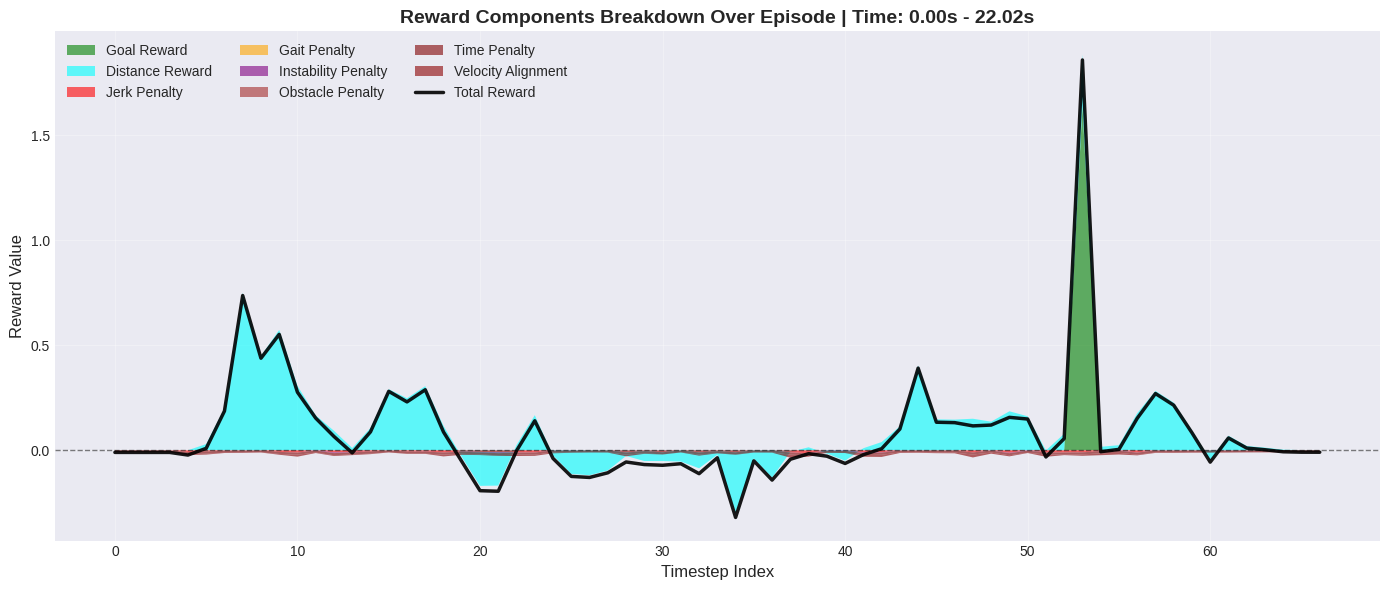

Breakdown visualization saved!


In [13]:
if episode_data and n_steps > 0:
    timesteps = np.arange(len(timestamps_trimmed))
    time_range = f"Time: {timestamps_trimmed[0]:.2f}s - {timestamps_trimmed[-1]:.2f}s"
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Separate positive and negative rewards for better visualization
    ax.stackplot(timesteps, 
                goal_rewards,
                distance_rewards,
                labels=['Goal Reward', 'Distance Reward'],
                colors=['green', 'cyan'],
                alpha=0.6)
    
    ax.stackplot(timesteps,
                jerk_penalties,
                gait_penalties,
                instability_penalties,
                obstacle_penalties,
                time_penalties,
                velocity_alignment_penalties,
                labels=['Jerk Penalty', 'Gait Penalty', 'Instability Penalty', 'Obstacle Penalty', 'Time Penalty', 'Velocity Alignment'],
                colors=['red', 'orange', 'purple', 'brown', 'maroon', 'darkred'],
                alpha=0.6)
    
    ax.plot(timesteps, total_rewards, 'k-', linewidth=2.5, label='Total Reward', alpha=0.9)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Timestep Index', fontsize=12)
    ax.set_ylabel('Reward Value', fontsize=12)
    ax.set_title(f'Reward Components Breakdown Over Episode | {time_range}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10, ncol=3)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/reward_breakdown.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Breakdown visualization saved!")
else:
    print("Cannot visualize: no episode data available")

## Section 5: Trajectory Visualization with Reward Overlay

Visualize the robot's exploration path in 2D/3D with reward heatmaps and sensor observations.

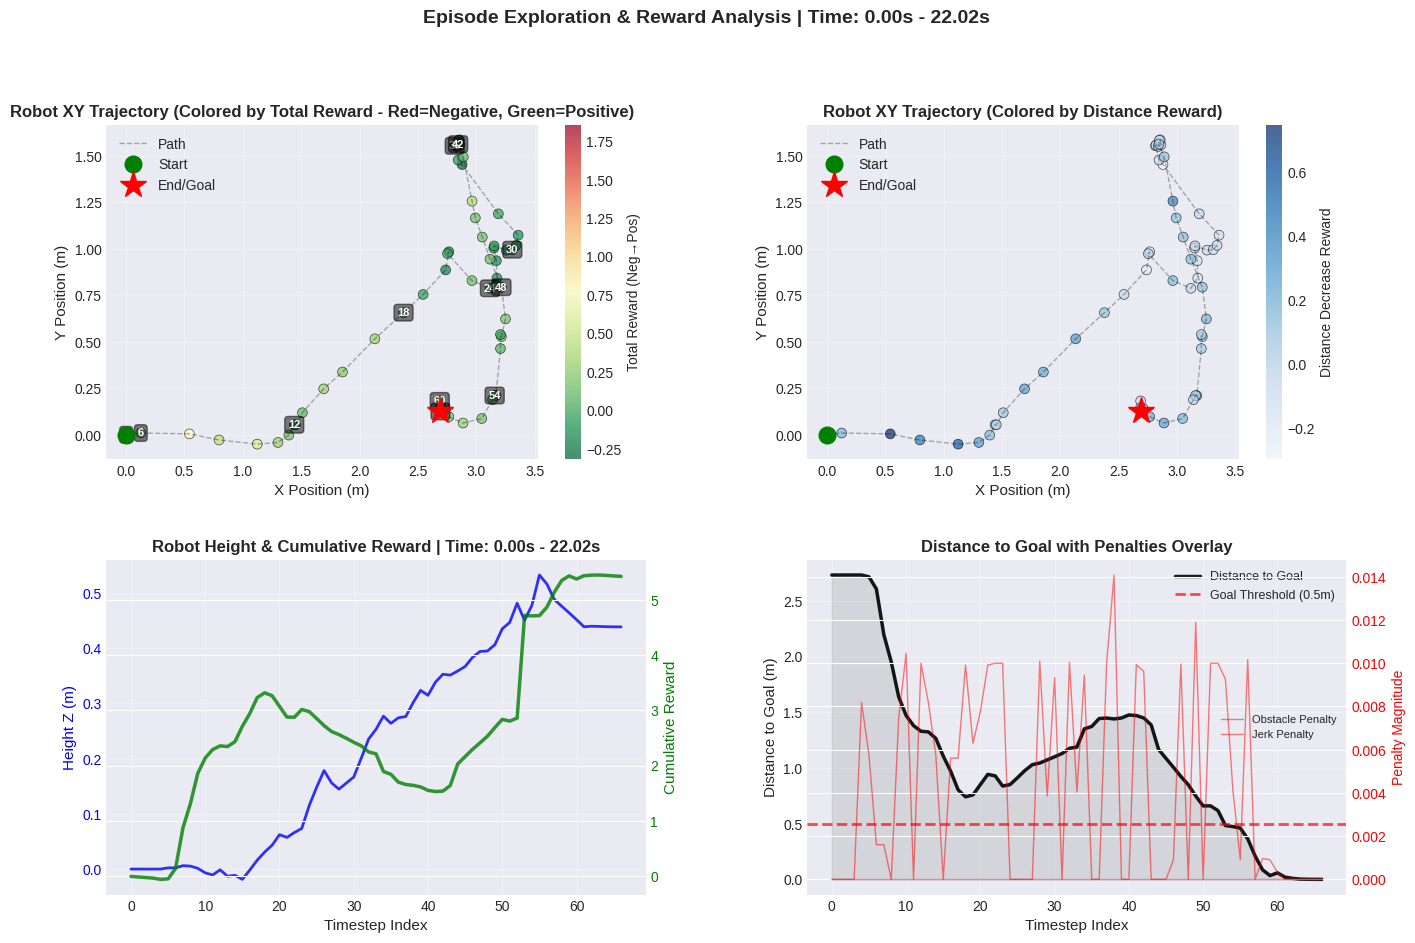

Trajectory visualization saved!


In [14]:
if episode_data and n_steps > 0 and states is not None:
    # Extract 2D trajectory from states (x, y positions) - trim to match reward arrays
    positions = states[:min_len, :3]  # [min_len, 3] -> x, y, z (trimmed to match reward computation)
    timesteps = np.arange(len(timestamps_trimmed))
    time_range = f"Time: {timestamps_trimmed[0]:.2f}s - {timestamps_trimmed[-1]:.2f}s"
    
    # Create comprehensive trajectory visualization
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
    
    # 1. XY Trajectory with total reward coloring (red=negative, green=positive)
    ax1 = fig.add_subplot(gs[0, 0])
    # Use RdYlGn_r for red (negative) to green (positive) with yellow in middle
    # Set vmin/vmax explicitly so min reward is red and max reward is green
    reward_min = np.min(total_rewards)
    reward_max = np.max(total_rewards)
    scatter1 = ax1.scatter(positions[:, 0], positions[:, 1], c=total_rewards, 
                           cmap='RdYlGn_r', s=50, alpha=0.7, edgecolors='black', linewidth=0.5,
                           vmin=reward_min, vmax=reward_max)
    ax1.plot(positions[:, 0], positions[:, 1], 'k--', alpha=0.3, linewidth=1, label='Path')
    ax1.plot(positions[0, 0], positions[0, 1], 'go', markersize=12, label='Start', zorder=5)
    ax1.plot(positions[-1, 0], positions[-1, 1], 'r*', markersize=20, label='End/Goal', zorder=5)
    
    # Add timestep labels to dots (sample every Nth point to avoid clutter)
    step_labels = min(8, max_len // 10)  # Show ~10 labels or fewer
    if step_labels < 1:
        step_labels = 1
    for i in range(0, len(positions), max(1, len(positions) // 10)):
        ax1.text(positions[i, 0], positions[i, 1], str(i), fontsize=8, 
                ha='center', va='center', color='white', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5))
    
    ax1.set_xlabel('X Position (m)', fontsize=11)
    ax1.set_ylabel('Y Position (m)', fontsize=11)
    ax1.set_title('Robot XY Trajectory (Colored by Total Reward - Red=Negative, Green=Positive)', fontsize=12, fontweight='bold')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    cbar1 = plt.colorbar(scatter1, ax=ax1)
    cbar1.set_label('Total Reward (Neg→Pos)', fontsize=10)
    
    # 2. XY Trajectory with distance reward coloring
    ax2 = fig.add_subplot(gs[0, 1])
    scatter2 = ax2.scatter(positions[:, 0], positions[:, 1], c=distance_rewards, 
                           cmap='Blues', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax2.plot(positions[:, 0], positions[:, 1], 'k--', alpha=0.3, linewidth=1, label='Path')
    ax2.plot(positions[0, 0], positions[0, 1], 'go', markersize=12, label='Start', zorder=5)
    ax2.plot(positions[-1, 0], positions[-1, 1], 'r*', markersize=20, label='End/Goal', zorder=5)
    ax2.set_xlabel('X Position (m)', fontsize=11)
    ax2.set_ylabel('Y Position (m)', fontsize=11)
    ax2.set_title('Robot XY Trajectory (Colored by Distance Reward)', fontsize=12, fontweight='bold')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    cbar2 = plt.colorbar(scatter2, ax=ax2)
    cbar2.set_label('Distance Decrease Reward', fontsize=10)
    
    # 3. Height (Z) vs cumulative reward
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(timesteps, positions[:min_len, 2], 'b-', linewidth=2, label='Robot Height', alpha=0.8)
    ax3_twin = ax3.twinx()
    ax3_twin.plot(timesteps, cumulative_reward, 'g-', linewidth=2.5, label='Cumulative Reward', alpha=0.8)
    ax3.set_xlabel('Timestep Index', fontsize=11)
    ax3.set_ylabel('Height Z (m)', fontsize=11, color='b')
    ax3_twin.set_ylabel('Cumulative Reward', fontsize=11, color='g')
    ax3.set_title(f'Robot Height & Cumulative Reward | {time_range}', fontsize=12, fontweight='bold')
    ax3.tick_params(axis='y', labelcolor='b')
    ax3_twin.tick_params(axis='y', labelcolor='g')
    ax3.grid(True, alpha=0.3)
    
    # 4. Distance to goal vs rewards (all penalty components)
    ax4 = fig.add_subplot(gs[1, 1])
    goal_pos = np.array(reward_computer.goal_position[:3])
    distances_to_goal = np.linalg.norm(positions - goal_pos, axis=1)
    
    ax4_main = ax4
    ax4_main.plot(timesteps, distances_to_goal, 'k-', linewidth=2.5, label='Distance to Goal', alpha=0.9)
    ax4_main.axhline(reward_computer.goal_threshold, color='r', linestyle='--', linewidth=2, 
                     label=f'Goal Threshold ({reward_computer.goal_threshold}m)', alpha=0.7)
    ax4_main.fill_between(timesteps, 0, distances_to_goal, alpha=0.2, color='gray')
    ax4_main.set_xlabel('Timestep Index', fontsize=11)
    ax4_main.set_ylabel('Distance to Goal (m)', fontsize=11)
    ax4_main.set_title('Distance to Goal with Penalties Overlay', fontsize=12, fontweight='bold')
    ax4_main.legend(loc='upper right', fontsize=9)
    ax4_main.grid(True, alpha=0.3)
    
    # Add penalty curves as semi-transparent overlays
    ax4_twin = ax4_main.twinx()
    ax4_twin.plot(timesteps, -obstacle_penalties, 'brown', linewidth=1, alpha=0.5, label='Obstacle Penalty')
    ax4_twin.plot(timesteps, -jerk_penalties, 'r', linewidth=1, alpha=0.5, label='Jerk Penalty')
    ax4_twin.set_ylabel('Penalty Magnitude', fontsize=10, color='red')
    ax4_twin.tick_params(axis='y', labelcolor='red')
    ax4_twin.legend(loc='center right', fontsize=8)
    
    fig.suptitle(f'Episode Exploration & Reward Analysis | {time_range}', fontsize=14, fontweight='bold', y=0.995)
    plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/trajectory_rewards.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Trajectory visualization saved!")
else:
    print("Cannot visualize trajectory: missing states or episode data")